# Slow-trend EDR on a rotated-MNIST single lap

Artifact-only summary of the Phase 5 path $0^\circ\to30^\circ\to0^\circ$. The experiment asks whether a longer trend half-life stabilizes the exponentially discounted risk (EDR) composition recommendation in a low-data setting with $m=4$ observations per update.

In [1]:
from pathlib import Path
import sys

repo_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'mnist_experiment' / 'plan5.md').is_file()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from mnist_experiment.rotated_mnist.phase5_single_lap_artifacts import (
    load_completed_single_lap_run,
)

run_id = 'rotated_mnist_phase5_slow_single_lap_development__replica-0001__30f2161a06eb8d50'
run_path = (
    repo_root / 'cache' / 'mnist_experiment' / 'rotated_mnist' /
    'phase5' / 'single_lap' / run_id
)
if not (run_path / 'COMPLETED').is_file():
    raise FileNotFoundError(f'Completed single-lap artifact not found: {run_path}')
run = load_completed_single_lap_run(run_path)
print(run.path)
print('Classification:', run.run_summary['retry_classification']['classification'])

/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/phase5/single_lap/rotated_mnist_phase5_slow_single_lap_development__replica-0001__30f2161a06eb8d50
Classification: stop


## What linear and sigmoid mean

**Linear** and **sigmoid** name the environmental rotation schedules, not different definitions of accuracy. Both schedules contain 40 updates from $0^\circ$ to $30^\circ$ and 40 updates back to $0^\circ$, use the same observation identities and labels, and therefore contain 320 online observations.

The linear schedule changes angle by $0.75^\circ$ per update. The sigmoid schedule uses the endpoint-normalized logistic progress

$$
r(z)=\frac{\sigma(\kappa(z-1/2))-\sigma(-\kappa/2)}{\sigma(\kappa/2)-\sigma(-\kappa/2)},\qquad \kappa=8,
$$

within each leg. It moves slowly near $0^\circ$ and $30^\circ$ and quickly near the middle.

At each update, **environmental multiclass accuracy** evaluates the model on all ten digits rotated to the current environmental angle. The reported accuracy AUC is its trapezoidal average over cumulative online observations, not a separate kind of accuracy.

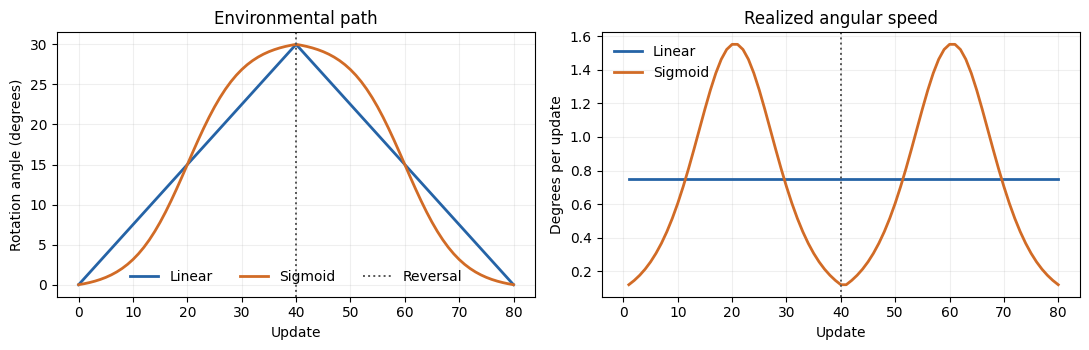

In [2]:
edr_condition = 'edr_slowtrend_slowaction'
schedule_frames = {}
for schedule in ('linear', 'sigmoid'):
    source = run.trajectory_metrics[schedule][edr_condition]
    schedule_frames[schedule] = pd.DataFrame([
        {
            'step': row['step'],
            'angle_degrees': row['angle_degrees'],
            'lagged_speed': row['lagged_angular_speed_degrees_per_update'],
        }
        for row in source
    ])

colors = {'linear': '#2563a6', 'sigmoid': '#d16b26'}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for schedule, frame in schedule_frames.items():
    axes[0].plot(frame['step'], frame['angle_degrees'], color=colors[schedule], linewidth=2, label=schedule.title())
    axes[1].plot(frame['step'], frame['lagged_speed'], color=colors[schedule], linewidth=2, label=schedule.title())
for axis in axes:
    axis.axvline(40, color='#555555', linestyle=':', linewidth=1.4, label='Reversal' if axis is axes[0] else None)
    axis.grid(alpha=.2)
    axis.set_xlabel('Update')
axes[0].set(title='Environmental path', ylabel='Rotation angle (degrees)')
axes[1].set(title='Realized angular speed', ylabel='Degrees per update')
axes[0].legend(frameon=False, ncol=3)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## Realized EDR sequence

EDR exponentially averages the predictable old-risk and new-risk coefficients and applies

$$
\pi_t^{\mathrm{EDR}}=\frac{\bar A_t}{\bar A_t+\bar B_t}.
$$

Here $H_\varphi=7.5^\circ$ smooths the local parameter trend and $H_\pi=8$ updates smooths the risk coefficients. The first eight actions are fixed at $.05$ while those estimates accumulate.

There is one development replica, so the curves below are **single realized EDR trajectories**, not means over independent replicas. The EDR action itself is already an exponentially averaged recommendation; averaging the linear and sigmoid interventions together would obscure the treatment difference.

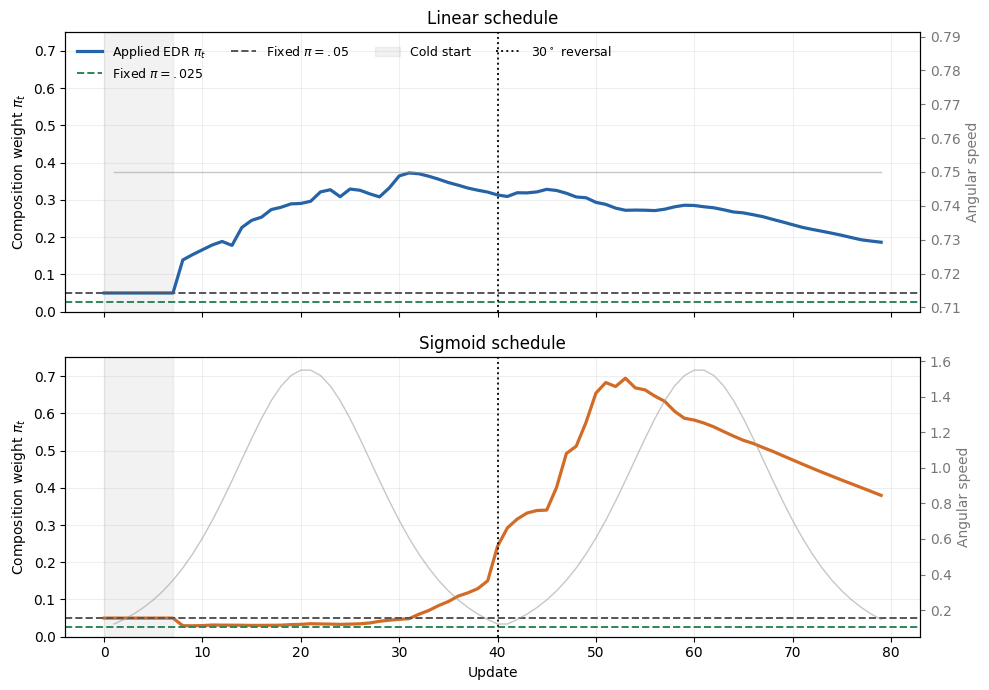

In [3]:
action_rows = []
for schedule in ('linear', 'sigmoid'):
    for row in run.trajectory_metrics[schedule][edr_condition]:
        controller = row['controller']
        if controller is None:
            continue
        action_rows.append({
            'schedule': schedule,
            'step': row['step'],
            'leg_id': row['leg_id'],
            'angle_degrees': row['angle_degrees'],
            'speed': row['lagged_angular_speed_degrees_per_update'],
            'applied_pi': controller['applied_pi'],
            'cold_start': controller['cold_start_active'],
        })
actions = pd.DataFrame(action_rows)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, sharey=True)
for axis, schedule in zip(axes, ('linear', 'sigmoid')):
    frame = actions[actions['schedule'] == schedule]
    axis.plot(frame['step'], frame['applied_pi'], color=colors[schedule], linewidth=2.3, label=r'Applied EDR $\pi_t$')
    axis.axhline(.025, color='#2f855a', linestyle='--', linewidth=1.4, label=r'Fixed $\pi=.025$')
    axis.axhline(.05, color='#555555', linestyle='--', linewidth=1.4, label=r'Fixed $\pi=.05$')
    axis.axvspan(0, 7, color='#999999', alpha=.12, label='Cold start')
    axis.axvline(40, color='#111111', linestyle=':', linewidth=1.4, label=r'$30^\circ$ reversal')
    axis.set(title=f'{schedule.title()} schedule', ylabel=r'Composition weight $\pi_t$', ylim=(0, .75))
    axis.grid(alpha=.2)
    speed_axis = axis.twinx()
    speed_axis.plot(frame['step'], frame['speed'], color='#999999', linewidth=1, alpha=.55)
    speed_axis.set_ylabel('Angular speed', color='#777777')
    speed_axis.tick_params(axis='y', colors='#777777')
axes[-1].set_xlabel('Update')
axes[0].legend(frameon=False, ncol=4, fontsize=9, loc='upper left')
fig.tight_layout()
plt.show()

In [4]:
post_cold = actions[~actions['cold_start']].copy()
post_cold['leg'] = post_cold['leg_id'].map({0: 'Outward', 1: 'Return'})
action_summary = (
    post_cold.groupby(['schedule', 'leg'])['applied_pi']
    .agg(['mean', 'min', 'max'])
    .reset_index()
)
display(action_summary.style.format({'mean': '{:.4f}', 'min': '{:.4f}', 'max': '{:.4f}'}))

,schedule,leg,mean,min,max
0,linear,Outward,0.2881,0.1387,0.3724
1,linear,Return,0.2673,0.1863,0.3284
2,sigmoid,Outward,0.0512,0.0294,0.1502
3,sigmoid,Return,0.4990,0.2429,0.6942


## Predictive consequences

The four policies below are paired within each schedule. Fixed $.05$ is the prospective baseline; fixed $.025$ is the better value learned post facto from this research program. Current-only uses no EWC summary. The vertical line separates outward adaptation from return to the upright environment.

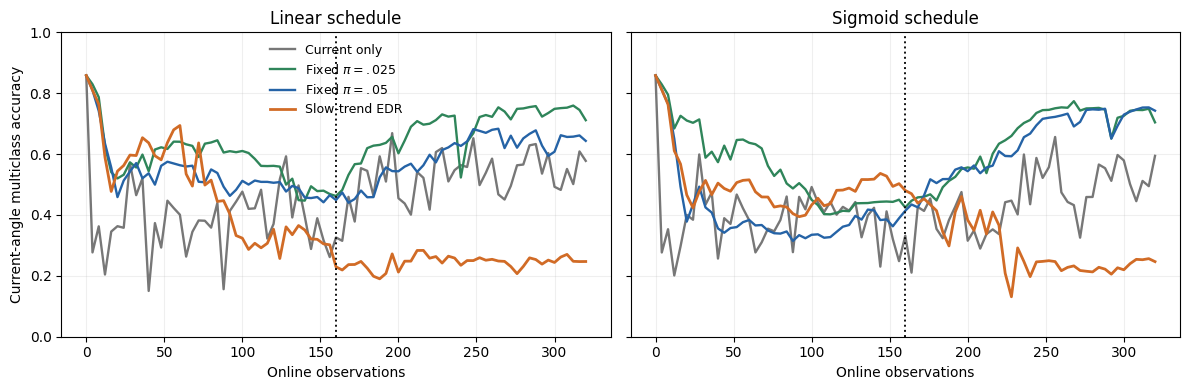

,schedule,policy,accuracy AUC,outward accuracy AUC,return accuracy AUC,NLL AUC,final upright accuracy
0,Linear,Current only,0.4555,0.3868,0.5243,10.498,0.5777
1,Linear,Fixed \pi=.025,0.6331,0.5842,0.6819,2.138,0.7113
2,Linear,Fixed \pi=.05,0.5630,0.5316,0.5944,2.723,0.6434
3,Linear,Slow-trend EDR,0.3603,0.4763,0.2444,36.101,0.2471
4,Sigmoid,Current only,0.4167,0.3855,0.4478,10.577,0.5942
5,Sigmoid,Fixed \pi=.025,0.5989,0.5510,0.6468,2.153,0.7042
6,Sigmoid,Fixed \pi=.05,0.5200,0.4070,0.6330,3.787,0.7426
7,Sigmoid,Slow-trend EDR,0.3973,0.4986,0.2961,30.538,0.2467


In [5]:
condition_labels = {
    'current_only': 'Current only',
    'fixed_pi0025': r'Fixed $\pi=.025$',
    'fixed_pi005': r'Fixed $\pi=.05$',
    edr_condition: 'Slow-trend EDR',
}
condition_colors = {
    'current_only': '#777777',
    'fixed_pi0025': '#2f855a',
    'fixed_pi005': '#2563a6',
    edr_condition: '#d16b26',
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for axis, schedule in zip(axes, ('linear', 'sigmoid')):
    for condition in run.config.conditions:
        frame = pd.DataFrame(run.trajectory_metrics[schedule][condition])
        axis.plot(
            frame['observations_before_evaluation'],
            frame['current_environment_accuracy'],
            color=condition_colors[condition],
            linewidth=2 if condition == edr_condition else 1.7,
            label=condition_labels[condition],
        )
    axis.axvline(160, color='#111111', linestyle=':', linewidth=1.4)
    axis.set(title=f'{schedule.title()} schedule', xlabel='Online observations', ylim=(0, 1))
    axis.grid(alpha=.2)
axes[0].set_ylabel('Current-angle multiclass accuracy')
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

summary_rows = []
for schedule in ('linear', 'sigmoid'):
    for condition in run.config.conditions:
        value = run.run_summary['condition_summaries'][schedule][condition]
        summary_rows.append({
            'schedule': schedule.title(),
            'policy': condition_labels[condition].replace('$', ''),
            'accuracy AUC': value['environment_accuracy_auc'],
            'outward accuracy AUC': value['first_ascent_environment_accuracy_auc'],
            'return accuracy AUC': value['return_environment_accuracy_auc'],
            'NLL AUC': value['environment_nll_auc'],
            'final upright accuracy': value['final_upright_environment_accuracy'],
        })
summary_table = pd.DataFrame(summary_rows)
display(summary_table.style.format({
    'accuracy AUC': '{:.4f}',
    'outward accuracy AUC': '{:.4f}',
    'return accuracy AUC': '{:.4f}',
    'NLL AUC': '{:.3f}',
    'final upright accuracy': '{:.4f}',
}))

## Finding

The retry is classified **stop** for this closed-loop controller. Slower trend estimation suppresses early noisy action on the gently starting sigmoid path: outward-leg EDR averages $\pi=.0512$ and attains accuracy AUC $.4986$, versus $.4070$ for fixed $.05$ and $.3855$ for current-only.

The recommendation arrives too late. It rises near the $30^\circ$ endpoint, persists after reversal, and reaches $.6942$ on the return leg. Return accuracy AUC then falls to $.2961$, versus $.6330$ for fixed $.05$. On the constant-speed schedule, EDR is elevated throughout both legs.

This is evidence that the estimated risk sequence contains some adaptation signal, but longer smoothing exchanges immediate variance for damaging lag. One development trajectory provides no confidence interval or general claim about adaptive composition. The next controller hypothesis would need estimator confidence or explicit change/reversal handling rather than another unstructured half-life search.